<h1 style="text-align:center; font-weight:bold;">
GYM MEMBER DATA ANALYSIS USING PANDAS
</h1>

<h2 style="font-weight:bold;">INTRODUCTION</h2>

<p style="font-size:16px;">
This project focuses on analyzing gym member data to understand workout patterns, attendance behavior, and overall fitness trends. The dataset contains important information such as age, gender, membership type, workout type, workout duration, calories burned, and attendance status.
</p>

<p style="font-size:16px;">
The main objective of this project is to use the Pandas library to explore and analyze the dataset in order to extract meaningful insights. By examining different factors, the analysis helps in identifying patterns that influence member engagement, workout efficiency, and attendance.
</p>

<p style="font-size:16px;">
The findings from this analysis can be useful for improving gym services, designing better fitness programs, and increasing member participation.
</p>

<h2 style="font-weight:bold;">IMPORTING LIBRARIES</h2>

<p style="font-size:16px;">
In this step, the required Python libraries were imported to perform data analysis and visualization. Pandas is used for data manipulation and analysis, NumPy is used for numerical operations, and Matplotlib is used for creating visualizations.
</p>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

<h2 style="font-weight:bold;">LOADING THE DATASET</h2>

<p style="font-size:16px;">
The dataset was loaded into the project using the Pandas library. The <code>read_csv()</code> function was used to import the data from a CSV file into a DataFrame. The first 10 rows of the dataset were displayed to understand its structure and contents.
</p>

In [2]:
df = pd.read_csv(r"C:\Users\user\Downloads\daily_gym_attendance_workout_data.csv")
print(df.head(10))

   member_id  visit_date  age  gender membership_type       workout_type  \
0          1  2024-10-11   64   Other          Annual               HIIT   
1          2  2024-06-01   65  Female       Quarterly  Strength Training   
2          3  2024-06-13   45    Male       Quarterly             Cardio   
3          4  2024-02-05   35  Female         Monthly           CrossFit   
4          5  2024-07-13   26  Female       Quarterly               Yoga   
5          6  2024-09-11   45   Other       Quarterly             Cardio   
6          7  2024-02-22   30   Other       Quarterly           CrossFit   
7          8  2024-05-04   38    Male          Annual               Yoga   
8          9  2024-02-10   61  Female         Monthly           CrossFit   
9         10  2024-08-14   36   Other       Quarterly  Strength Training   

   workout_duration_minutes  calories_burned check_in_time attendance_status  
0                        28              171         20:04            Absent  
1    

<h2 style="font-weight:bold;">DATA CLEANING</h2>

<p style="font-size:16px;">
In this step, the dataset was checked for missing values, duplicate records, and data inconsistencies. Data cleaning is essential to ensure the accuracy and reliability of the analysis.
</p>

<p style="font-size:16px;">
Missing values were identified and handled appropriately, duplicate records were removed, and data types were verified to maintain consistency across all variables.
</p>

In [4]:
df.isnull().sum()

member_id                   0
visit_date                  0
age                         0
gender                      0
membership_type             0
workout_type                0
workout_duration_minutes    0
calories_burned             0
check_in_time               0
attendance_status           0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.dtypes

member_id                            int64
visit_date                  datetime64[ns]
age                                  int64
gender                              object
membership_type                     object
workout_type                        object
workout_duration_minutes             int64
calories_burned                      int64
check_in_time                       object
attendance_status                   object
dtype: object

In [3]:
df['visit_date'] = pd.to_datetime(df['visit_date'])

In [4]:
df['check_in_time'] = pd.to_datetime(df['check_in_time'], format='%H:%M')

In [5]:
df.dtypes

member_id                            int64
visit_date                  datetime64[ns]
age                                  int64
gender                              object
membership_type                     object
workout_type                        object
workout_duration_minutes             int64
calories_burned                      int64
check_in_time               datetime64[ns]
attendance_status                   object
dtype: object

Q1 how many rows and columns are in the dataset

In [12]:
df.shape

(2600, 10)

Q2 find the average age of members

In [14]:
print("Averege age :", round(df['age'].mean(), 2))

Averege age : 41.95


Q3 find the maximum and minimum calories burned

In [ ]:
print('Maximum calories burned:',df['calories_burned'].max())
print('Minimum calories burned:',df['calories_burned'].min())

Maximum calories burned: 1186
Minimum calories burned: 102


Q4 how many members attended vs absent?

In [16]:
df['attendance_status'].value_counts()

attendance_status
Absent     1350
Present    1250
Name: count, dtype: int64

Q5 what is the average workout duration by gender


gender
Female    69.391648
Male      69.897767
Other     71.215527
Name: workout_duration_minutes, dtype: float64


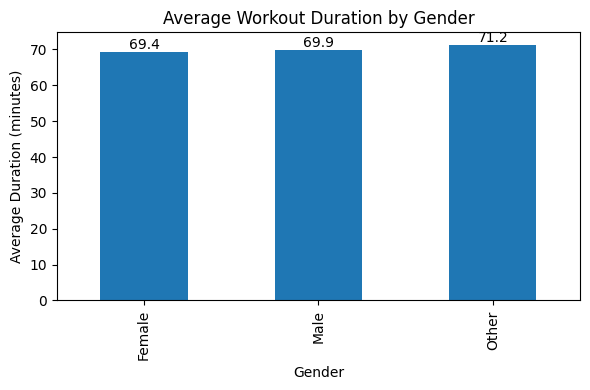

In [ ]:
avg_workout = df.groupby('gender')['workout_duration_minutes'].mean()

print(avg_workout)

ax = avg_workout.plot(kind='bar', figsize=(6,4))

plt.title('Average Workout Duration by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Duration (minutes)')


for i, v in enumerate(avg_workout):
    ax.text(i, v, f'{v:.1f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

The average workout duration is nearly similar across all genders, with only minor variations, indicating no significant difference based on gender.

Q6 which workout types burns the highest average calories?

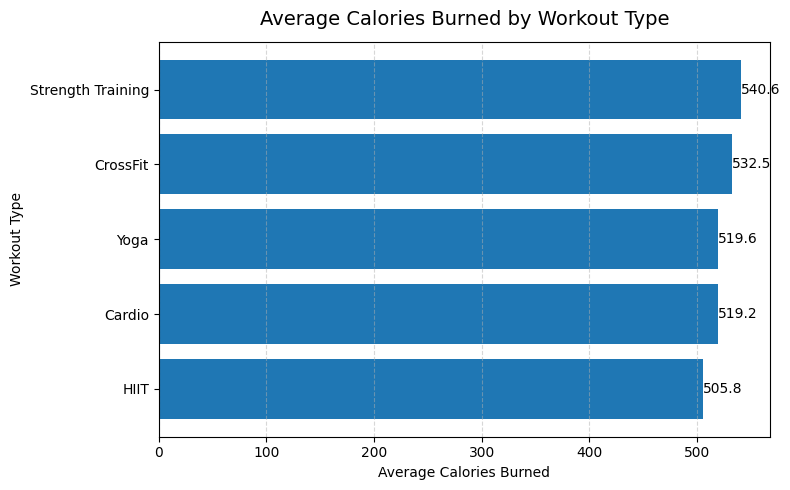

In [34]:
avg_cal = df.groupby('workout_type')['calories_burned'] \
            .mean() \
            .sort_values()

plt.figure(figsize=(8,5))
bars = plt.barh(avg_cal.index, avg_cal.values)

plt.title('Average Calories Burned by Workout Type', fontsize=14, pad=12)
plt.xlabel('Average Calories Burned')
plt.ylabel('Workout Type')


for i, v in enumerate(avg_cal):
    plt.text(v, i, f'{v:.1f}', va='center', fontsize=10)


plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

The chart shows that strength training has the highest average calorie expenditure, while HIIT has the lowest. However, the differences across workout types are relatively small, indicating that most workouts provide similar calorie-burning benefits.

Q7 Does membership type influence the average calories burned during workouts?

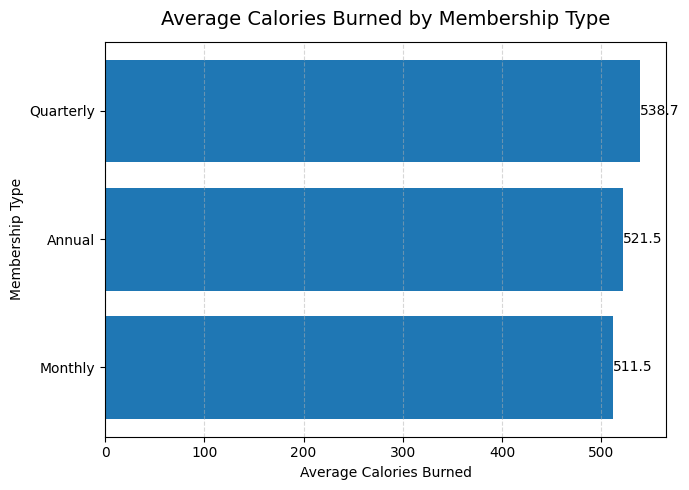

In [35]:
avg_cal = df.groupby('membership_type')['calories_burned'] \
            .mean() \
            .sort_values()

plt.figure(figsize=(7,5))
bars = plt.barh(avg_cal.index, avg_cal.values)

plt.title('Average Calories Burned by Membership Type', fontsize=14, pad=12)
plt.xlabel('Average Calories Burned')
plt.ylabel('Membership Type')

for i, v in enumerate(avg_cal):
    plt.text(v, i, f'{v:.1f}', va='center')

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

The analysis indicates that membership type does not significantly influence calorie expenditure, as only minor differences were observed across categories.

Q8 Extract hour from check in time?

In [7]:
df['hour']= df['check_in_time'].dt.hour
print(df.head(5))

   member_id visit_date  age  gender membership_type       workout_type  \
0          1 2024-10-11   64   Other          Annual               HIIT   
1          2 2024-06-01   65  Female       Quarterly  Strength Training   
2          3 2024-06-13   45    Male       Quarterly             Cardio   
3          4 2024-02-05   35  Female         Monthly           CrossFit   
4          5 2024-07-13   26  Female       Quarterly               Yoga   

   workout_duration_minutes  calories_burned       check_in_time  \
0                        28              171 1900-01-01 20:04:00   
1                        72              650 1900-01-01 19:17:00   
2                        70              633 1900-01-01 07:24:00   
3                        64              362 1900-01-01 07:18:00   
4                        31              262 1900-01-01 11:22:00   

  attendance_status  hour  
0            Absent    20  
1            Absent    19  
2            Absent     7  
3            Absent     7  


Q9 Analyze the distribution of gym check-ins across different hours of the day

hour
5     157
6     142
7     145
8     171
9     162
10    148
11    141
12    157
13    138
14    136
15    121
16    174
17    128
18    127
19    147
20    125
21    144
22    137
Name: count, dtype: int64


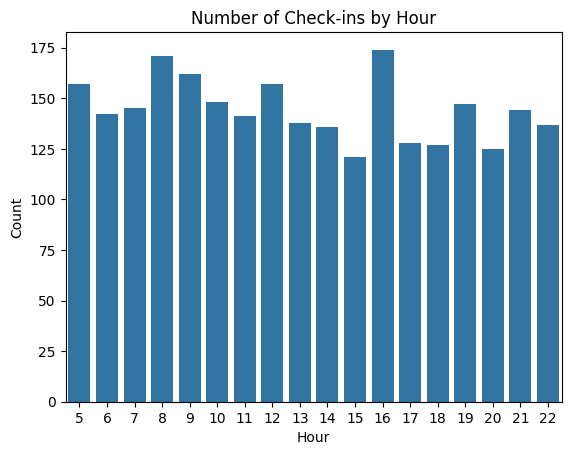

In [26]:
checkins = df['hour'].value_counts().sort_index()
print(checkins)

sns.barplot(x=checkins.index, y=checkins.values)
plt.title("Number of Check-ins by Hour")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.show()

The distribution of check-ins shows that gym attendance peaks in the late afternoon, particularly around 4 PM, with additional high activity during morning hours. Lower attendance is observed during early afternoon hours, suggesting that members prefer working out before or after typical working hours

Q10 “How does the average calories burned vary across different hours of the day?

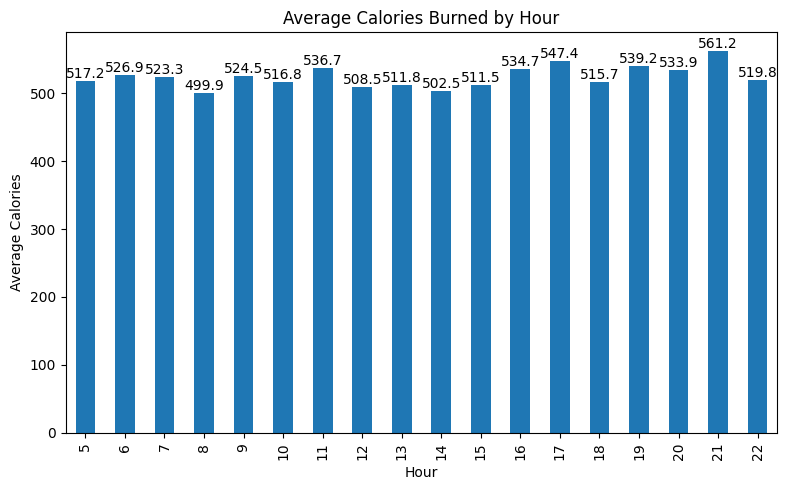

In [25]:
avg_cal = df.groupby('hour')['calories_burned'].mean()

ax = avg_cal.plot(kind='bar', figsize=(8,5))

plt.title('Average Calories Burned by Hour')
plt.xlabel('Hour')
plt.ylabel('Average Calories')

for i, v in enumerate(avg_cal):
    ax.text(i, v, f'{v:.1f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

The average calories burned shows minor variation across different hours of the day, with slightly higher values observed in the evening hours. However, the differences are not substantial, indicating that workout intensity remains relatively consistent regardless of time

Q11 Find the top 3 hours with the longest average workout duration

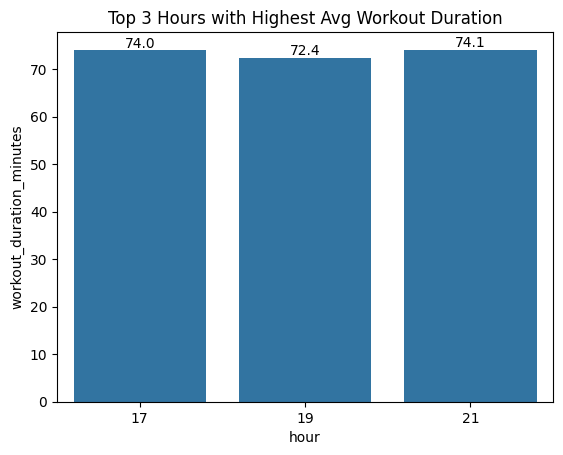

In [13]:

top3_hours = df.groupby('hour')['workout_duration_minutes'].mean().nlargest(3) .sort_values().reset_index()

ax = sns.barplot(x='hour', y='workout_duration_minutes', data=top3_hours)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.title('Top 3 Hours with Highest Avg Workout Duration')
plt.show()

The analysis shows that the highest average workout durations occur during evening hours, particularly around 5 PM to 9 PM. This suggests that members tend to spend more time exercising later in the day.”

Q12 How does the distribution of workout types vary across genders?

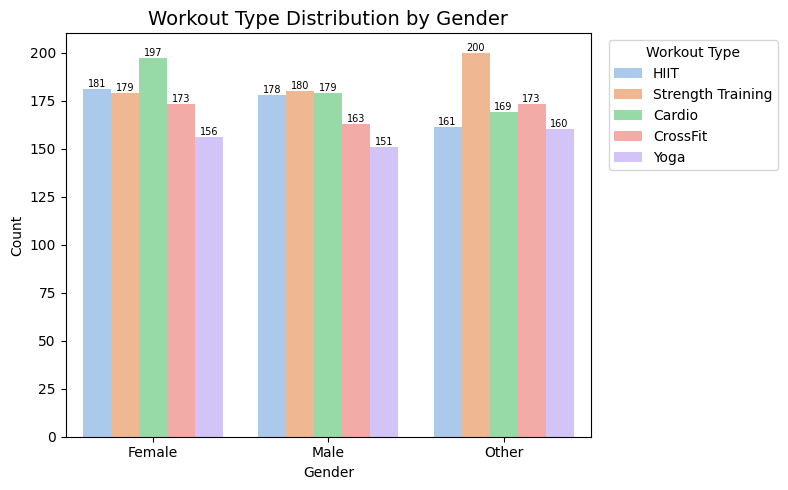

In [37]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x='gender',
    hue='workout_type',
    order=['Female', 'Male', 'Other'],
    palette='pastel'
)

plt.title('Workout Type Distribution by Gender', fontsize=14)
plt.xlabel('Gender')
plt.ylabel('Count')

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width()/2, height),
                    ha='center', va='bottom', fontsize=7)
        
plt.legend(title='Workout Type', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

The distribution of workout types across genders is fairly consistent, with only minor variations. Strength training and cardio are slightly more common, while yoga has the lowest participation across all groups.

Q13 Does attendance vary across different membership types?

In [19]:
pd.crosstab(df['membership_type'],
            df['attendance_status'],
            normalize='index') * 100

attendance_status,Absent,Present
membership_type,,
Annual,51.273533,48.726467
Monthly,50.700935,49.299065
Quarterly,53.864447,46.135553


Q14 Compute a new variable, calories_per_minute, to represent the rate of calories burned per minute during workouts.

In [20]:
df['calories_per_minute'] = (df['calories_burned'] / df['workout_duration_minutes'])
print(df.head(4))

   member_id visit_date  age  gender membership_type       workout_type  \
0          1 2024-10-11   64   Other          Annual               HIIT   
1          2 2024-06-01   65  Female       Quarterly  Strength Training   
2          3 2024-06-13   45    Male       Quarterly             Cardio   
3          4 2024-02-05   35  Female         Monthly           CrossFit   

   workout_duration_minutes  calories_burned       check_in_time  \
0                        28              171 1900-01-01 20:04:00   
1                        72              650 1900-01-01 19:17:00   
2                        70              633 1900-01-01 07:24:00   
3                        64              362 1900-01-01 07:18:00   

  attendance_status  hour  calories_per_minute  
0            Absent    20             6.107143  
1            Absent    19             9.027778  
2            Absent     7             9.042857  
3            Absent     7             5.656250  


Q15 Analyze the distribution of workout types among members who engage in workouts longer than 60 minutes.

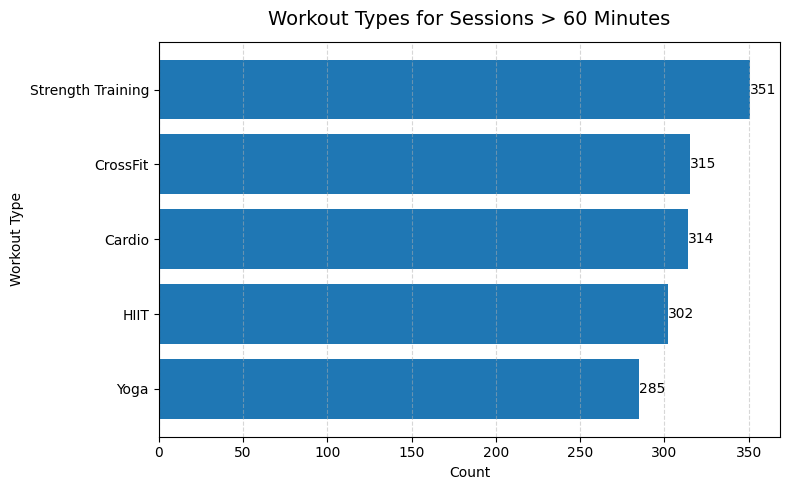

In [38]:
long_workouts = df[df['workout_duration_minutes'] > 60]

counts = long_workouts['workout_type'].value_counts().sort_values()

plt.figure(figsize=(8,5))
bars = plt.barh(counts.index, counts.values)

plt.title('Workout Types for Sessions > 60 Minutes', fontsize=14, pad=12)
plt.xlabel('Count')
plt.ylabel('Workout Type')

for i, v in enumerate(counts):
    plt.text(v, i, str(v), va='center', fontsize=10)

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Among workouts exceeding 60 minutes, strength training is the most common, while yoga is the least frequent. This suggests that longer workout sessions are more associated with high-intensity or strength-based activities

Q16 Analyze the difference between male and female members who burned more than the average calories

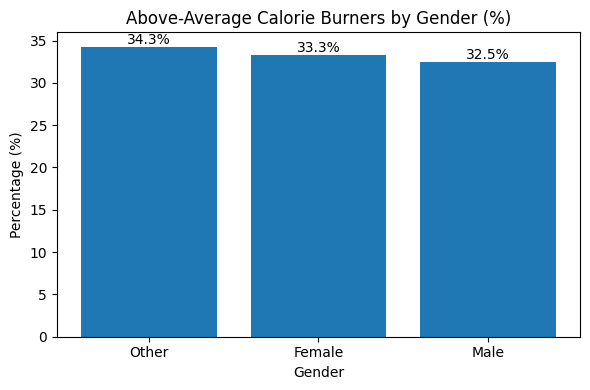

In [39]:
avg = df['calories_burned'].mean()
filtered = df[df['calories_burned'] > avg]

percent = filtered['gender'].value_counts(normalize=True) * 100

plt.figure(figsize=(6,4))
bars = plt.bar(percent.index, percent.values)

plt.title('Above-Average Calorie Burners by Gender (%)')
plt.xlabel('Gender')
plt.ylabel('Percentage (%)')

for i, v in enumerate(percent):
    plt.text(i, v, f'{v:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

The percentage of individuals burning above-average calories is nearly समान across all gender categories, with only minor variations. This indicates that gender does not significantly influence higher calorie expenditure

Q17 Which hour of the day has the highest average calories burned?

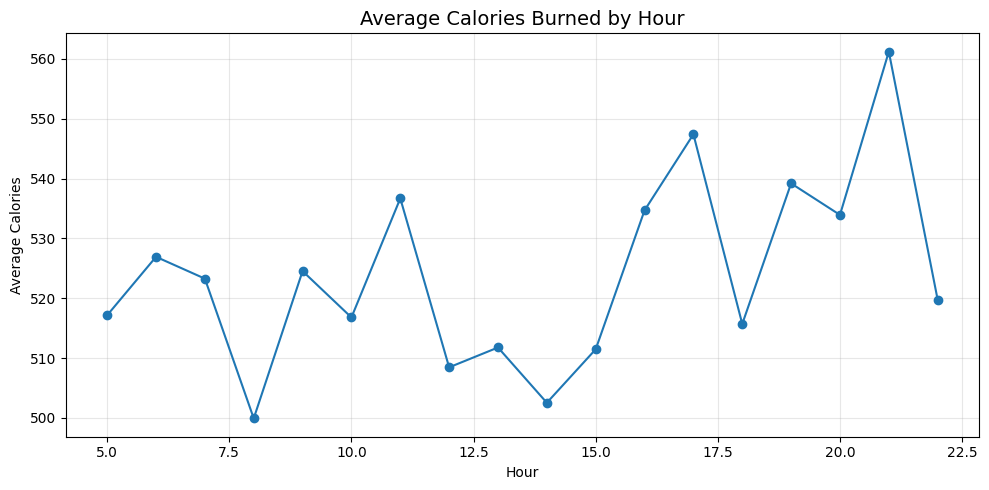

In [40]:
avg_cal = df.groupby('hour')['calories_burned'].mean()

plt.figure(figsize=(10,5))

plt.plot(avg_cal.index, avg_cal.values, marker='o')

plt.title('Average Calories Burned by Hour', fontsize=14)
plt.xlabel('Hour')
plt.ylabel('Average Calories')

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

The average calories burned show a mild upward trend during the evening hours, with the highest values observed around 9 PM. However, the variation across the day is relatively small, indicating consistent workout intensity regardless of time

Q18 Which workout type has highest calories per minute?

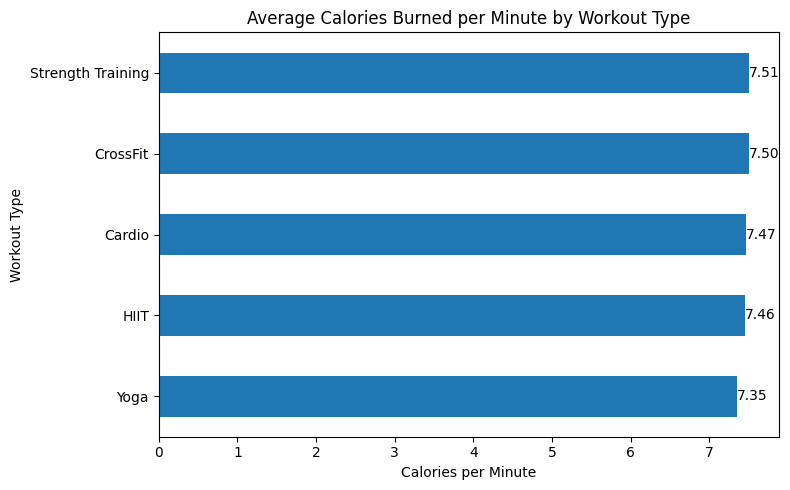

In [26]:
eff = df.groupby('workout_type')['calories_per_minute'].mean().sort_values()

ax = eff.plot(kind='barh', figsize=(8,5))

plt.title('Average Calories Burned per Minute by Workout Type')
plt.xlabel('Calories per Minute')
plt.ylabel('Workout Type')


for i, v in enumerate(eff):
    ax.text(v, i, f'{v:.2f}', va='center')

plt.tight_layout()
plt.show()

The average calories burned per minute are relatively consistent across all workout types, with only minimal differences. This suggests that workout efficiency is similar regardless of the type of exercise performed

Q19 Relationship between age and workout duration

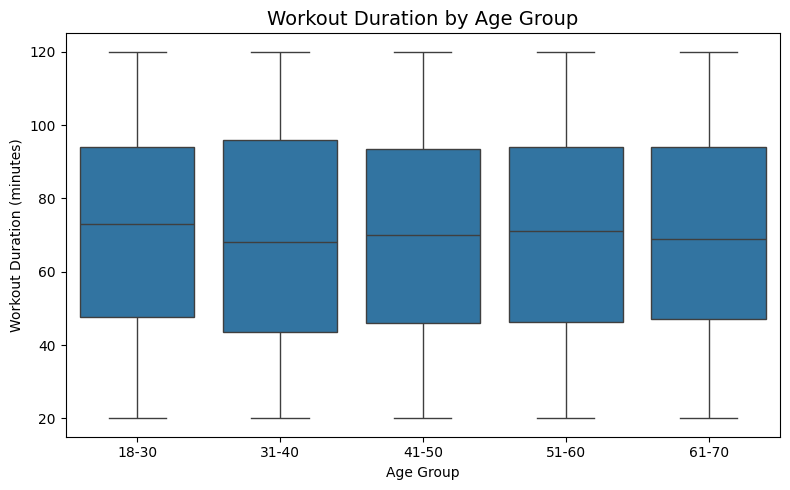

In [44]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[18,30,40,50,60,70],
    labels=['18-30','31-40','41-50','51-60','61-70']
)

plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='age_group', y='workout_duration_minutes')

plt.title('Workout Duration by Age Group', fontsize=14)
plt.xlabel('Age Group')
plt.ylabel('Workout Duration (minutes)')

plt.tight_layout()
plt.show()

Age was grouped into categories to simplify the analysis and enable meaningful comparison across different life stages. Analyzing individual ages would result in excessive variability and make patterns difficult to interpret. By grouping ages, the data becomes more structured and easier to compare.

A boxplot was chosen instead of a scatter plot because it effectively summarizes the distribution of workout duration within each age group. It highlights the median, spread, and variability of the data, making it easier to compare patterns across groups. In contrast, a scatter plot with many data points can become cluttered and may not clearly reveal overall trends.

Q20 Which workout type has the highest attendance rate?

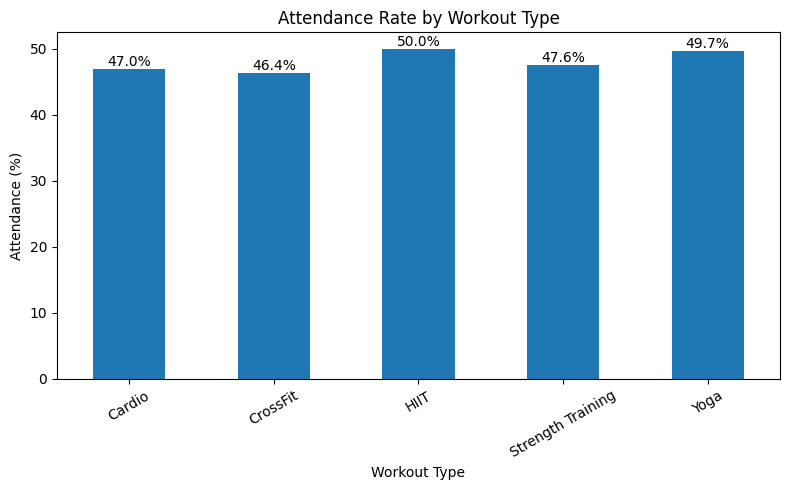

In [29]:
ct = pd.crosstab(df['workout_type'],
                 df['attendance_status'],
                 normalize='index') * 100

present_rate = ct['Present']

ax = present_rate.plot(kind='bar', figsize=(8,5))

plt.title('Attendance Rate by Workout Type')
plt.xlabel('Workout Type')
plt.ylabel('Attendance (%)')

for i, v in enumerate(present_rate):
    ax.text(i, v, f'{v:.1f}%', ha='center', va='bottom')

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Percentages were used for fair comparison across workout types, and a bar chart was chosen for clear visualization of attendance differences

<h2 style="font-weight:bold;">CONCLUSION</h2>

<p style="font-size:16px;">
This study examined workout behavior, attendance patterns, and performance among gym members. The analysis shows that workout preferences are largely consistent across different genders, with no major differences in the choice of workout types. Attendance rates are also similar across workout and membership categories, indicating that these factors do not significantly affect participation.
</p>

<p style="font-size:16px;">
The results further reveal that workout duration remains consistent across all age groups, suggesting that age does not play a significant role in determining how long individuals exercise. In addition, calorie-burning efficiency (calories per minute) is nearly identical across all workout types, indicating that no single workout is significantly more effective than others.
</p>

<p style="font-size:16px;">
Time-based analysis shows slightly higher workout intensity during evening hours, and longer sessions are more commonly associated with strength training. However, these variations are relatively small.
</p>

<p style="font-size:16px;">
Overall, the findings suggest that workout patterns are broadly uniform, and individual behavior is not strongly influenced by demographic or membership factors.
</p>